In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

from chessrl.utils.io import load_vf_parquet, load_policy_jsonl

from chessrl.eval.helpers import (
    optimal_moves_syzygy, 
    move_from_policy_map, 
    mcts_move_from_instance,
    policy_mlp_move_from_checkpoint
)

from chessrl.eval.evaluator import evaluate

# defining paths
TB_PATH = "./tablebase/krk/"

POLICY_PATH = "./artifacts/policies/"
VF_PATH = "./artifacts/values/"

2025-09-04 12:25:34,454 - INFO - Loading config file...


# KRK Endgame vs Oracle Defender

Instantiate the oracle in order to compare the learned policies against the optimal moves

In [2]:
from chessrl import SyzygyDefender

defender = SyzygyDefender(TB_PATH)

# dtm oracle
dtz_oracle = pd.read_csv(TB_PATH + "krk_full.csv").set_index("fen")["dtz"].to_dict()
dtm_oracle = lambda fen: abs(int(dtz_oracle[fen]))

# optimal moves source
opt_moves = optimal_moves_syzygy(TB_PATH)

## Generating test FENs

In [3]:
import numpy as np

def build_stratified_fens(
    df,
    dtz_col="dtz",
    fen_col="fen",
    exact_targets={1:50, 2:50, 3:50},            # fixed counts for specific DTZs
    bin_edges=( [4, 6, 8, 10, 15, 20, 30, 50, 100, np.inf] ),  # buckets for higher DTZ
    per_bin_target=50,                            # sample this many from each bucket
    random_state=42,
    allow_smaller=True,                           # if a group has fewer than target, take what's available
    drop_duplicate_fens=True,
    shuffle=True
):
    rng = np.random.RandomState(random_state)
    work = df.copy()

    # Optional de-dup (sometimes tablebases contain repeated FENs or semantically equivalent ones you’ve pre-collapsed)
    if drop_duplicate_fens:
        work = work.drop_duplicates(subset=[fen_col]).reset_index(drop=True)

    sampled_parts = []

    # 1) Exact targets for specific DTZs (e.g., “mate in 1/2/3” buckets)
    if exact_targets:
        g = work[work[dtz_col].isin(exact_targets.keys())].groupby(dtz_col, group_keys=False)
        exact_samples = []
        for v, grp in g:
            k = exact_targets.get(v, 0)
            if k <= 0: 
                continue
            n_take = min(k, len(grp)) if allow_smaller else k
            if n_take > len(grp):
                raise ValueError(f"Requested {k} for DTZ={v}, only {len(grp)} available.")
            exact_samples.append(grp.sample(n=n_take, random_state=rng))
        if exact_samples:
            exact_samples = pd.concat(exact_samples, ignore_index=True)
            sampled_parts.append(exact_samples)
            # remove chosen rows from future sampling
            work = work.drop(index=exact_samples.index)

    # 2) Bucket higher DTZ values and sample per bucket
    if bin_edges:
        # ensure lower edge is > max of exact keys (if you like); otherwise filter explicitly
        max_exact = max(exact_targets.keys()) if exact_targets else -np.inf
        high = work[work[dtz_col] > max_exact].copy()

        bins = [-np.inf] + bin_edges  # let the first cut catch everything <= first edge; we’ll filter next
        labels = []
        for lo, hi in zip(bins[:-1], bins[1:]):
            lo_txt = int(lo) if np.isfinite(lo) else ""
            hi_txt = (int(hi - 1) if np.isfinite(hi) else "inf")
            if np.isfinite(lo):
                labels.append(f"{int(lo)}–{hi_txt}")
            else:
                labels.append(f"<= {hi_txt}")

        high["dtz_bucket"] = pd.cut(high[dtz_col], bins=bins, labels=labels, right=True, include_lowest=True)

        # Optional: remove the bucket that includes the lower-than-first-edge items
        # since we already sampled exact DTZs. Keep only buckets strictly above max_exact.
        high = high[high[dtz_col] > max_exact]

        g = high.groupby("dtz_bucket", dropna=True, group_keys=False)
        bucket_samples = []
        for bucket_name, grp in g:
            if per_bin_target <= 0:
                continue
            n_take = min(per_bin_target, len(grp)) if allow_smaller else per_bin_target
            if n_take > len(grp):
                raise ValueError(f"Requested {per_bin_target} for bucket {bucket_name}, only {len(grp)} available.")
            bucket_samples.append(grp.sample(n=n_take, random_state=rng))

        if bucket_samples:
            bucket_samples = pd.concat(bucket_samples, ignore_index=True)
            sampled_parts.append(bucket_samples)

    # 3) Assemble final sample
    if sampled_parts:
        sampled_df = pd.concat(sampled_parts, ignore_index=True)
    else:
        sampled_df = pd.DataFrame(columns=df.columns)

    if shuffle:
        sampled_df = sampled_df.sample(frac=1.0, random_state=rng).reset_index(drop=True)

    return sampled_df



In [4]:
# Load the test data
test_df = pd.read_csv(TB_PATH + "krk_test.csv")

sampled_df = build_stratified_fens(
    test_df,
    dtz_col="dtz",
    fen_col="fen",
    exact_targets={1:10, 2:10, 3:10},
    bin_edges=[4,6,8,10,15,20,32],
    per_bin_target=50,
    random_state=42,
)

sorted_df = sampled_df.sort_values("dtz").reset_index(drop=True)
fens = sorted_df["fen"].to_list()   

/tmp/ipykernel_31526/3349640448.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = high.groupby("dtz_bucket", dropna=True, group_keys=False)


In [5]:
# Load the test data
train_df = pd.read_csv(TB_PATH + "krk_train.csv")

sampled_df = build_stratified_fens(
    train_df,
    dtz_col="dtz",
    fen_col="fen",
    exact_targets={1:10, 2:10, 3:10},
    bin_edges=[4,6,8,10,15,20,32],
    per_bin_target=50,
    random_state=42,
    shuffle=False
)

train_fens = sampled_df["fen"].to_list()

/tmp/ipykernel_31526/3349640448.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = high.groupby("dtz_bucket", dropna=True, group_keys=False)


## Value Iteration

### Policy Assessment

In [7]:
# instantiate the agent with the learned policy map
policy_map = load_policy_jsonl(POLICY_PATH + "vi_krk_greedy.jsonl")
vi_agent = move_from_policy_map(policy_map)


In [ ]:

# Evaluate the agent on the test FENs
df_vi = evaluate(vi_agent, defender, fens, dtm_oracle, optimal_moves=opt_moves)

Below we can see that all the positions are solved, against perfect defender, with optimal actions.

In [51]:
df_vi.groupby('dtm_oracle')['success'].mean()

dtm_oracle
1     1.0
3     1.0
5     1.0
7     1.0
9     1.0
11    1.0
13    1.0
15    1.0
17    1.0
19    1.0
21    1.0
23    1.0
25    1.0
27    1.0
29    1.0
31    1.0
Name: success, dtype: float64

the time required to take each move is independent of the position's difficulty, as measured by the DTM oracle.

In [50]:
df_vi.groupby('dtm_oracle')['ms_per_move'].mean()

dtm_oracle
1     0.002915
3     0.002744
5     0.002842
7     0.002665
9     0.002609
11    0.002757
13    0.002846
15    0.002954
17    0.002641
19    0.003326
21    0.002845
23    0.002772
25    0.002871
27    0.002773
29    0.002650
31    0.002545
Name: ms_per_move, dtype: float64

### Analysis of the value function

Interestingly value and dtz matches! This is not a surprise but a consequence of the way the reward function is designed, as it encourages the agent to find the fastest path to mate, specifically having a `step_penalty = -2` at each turn. Note that the step penalty is -2 and not -1 since the black reply is absorbed inside the environment step and the DTZ is defined in ply, *i.e.*, half-moves.

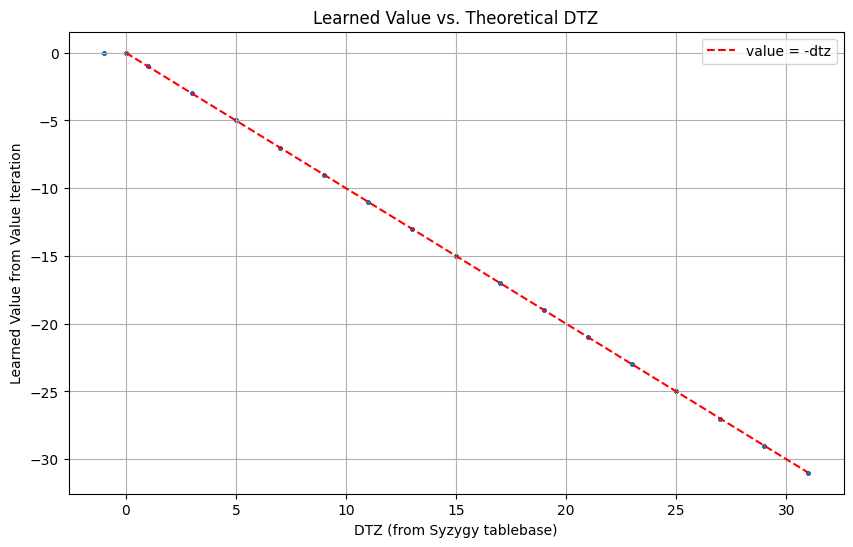

In [9]:
# load the value function
V = load_vf_parquet(VF_PATH + "vi_krk_values.parquet")

# build a df with the theoretical DTZ for each FEN
V_df = pd.DataFrame.from_dict(V, orient='index', columns=['value']).reset_index().rename(columns={'index': 'fen'})
V_df['dtz'] = V_df['fen'].map(dtz_oracle)
V_df['gap'] = V_df['value'] + V_df['dtz']
V_df.sort_values('value')

# Plotting the relationship between the learned value and the theoretical DTZ
plt.figure(figsize=(10, 6))
plt.scatter(V_df['dtz'], V_df['value'], alpha=0.1, s=5)
plt.title('Learned Value vs. Theoretical DTZ')
plt.xlabel('DTZ (from Syzygy tablebase)')
plt.ylabel('Learned Value from Value Iteration')

# Add a reference line for value = -dtz
max_dtz = V_df['dtz'].max()
if pd.notna(max_dtz):
    plt.plot([0, max_dtz], [0, -max_dtz], color='red', linestyle='--', label='value = -dtz')

plt.grid(True)
plt.legend()
plt.show()

the only gap between the value function and the DTZ is for positions where it is Black's turn to move but it is checkmate. This happens because the value is 0 (is not white to move) whereas by thefinition it has DTZ = -1

In [76]:
V_df[(V_df['gap'] != 0) & (V_df['fen'].str.contains('b'))]

,fen,value,dtz,gap
5711,8/8/8/8/8/R7/8/k1K5 b - - 0 1,0.0,-1.0,-1.0
5719,8/8/8/8/R7/8/8/k1K5 b - - 0 1,0.0,-1.0,-1.0
5727,8/8/8/R7/8/8/8/k1K5 b - - 0 1,0.0,-1.0,-1.0
5735,8/8/R7/8/8/8/8/k1K5 b - - 0 1,0.0,-1.0,-1.0
5743,8/R7/8/8/8/8/8/k1K5 b - - 0 1,0.0,-1.0,-1.0
...,...,...,...,...
182667,1k5K/8/8/8/8/8/8/8 b - - 0 1,0.0,NaN,NaN
182669,2k4K/8/8/8/8/8/8/8 b - - 0 1,0.0,NaN,NaN
182671,3k3K/8/8/8/8/8/8/8 b - - 0 1,0.0,NaN,NaN
182673,4k2K/8/8/8/8/8/8/8 b - - 0 1,0.0,NaN,NaN


Another interesting observation is that if we execute VI for $n$ iterations it is able to solve mates only up to $\text{DTZ} = 2n+1$

In [5]:
# build a dataset with one position for each dtz
example_df = build_stratified_fens(
    test_df,
    dtz_col="dtz",
    fen_col="fen",
    exact_targets={x:1 for x in range(1, 32, 2)},
    bin_edges=( [] ),
    per_bin_target=0,
    random_state=42,
    drop_duplicate_fens=False,
    shuffle=False
)
example_fens = example_df['fen'].tolist()

In [92]:
# instantiate the agent with the learned policy map
partial_policy_map = load_policy_jsonl(POLICY_PATH + "vi_krk_greedy_intermediate_9.jsonl")
partial_vi_agent = move_from_policy_map(partial_policy_map)

# Evaluate the agent on the test FENs
example_df_vi = evaluate(partial_vi_agent, defender, example_fens, dtm_oracle, optimal_moves=opt_moves)

In [93]:
example_df_vi

,fen,dtm_policy,dtm_oracle,gap,success,ms_per_move,top1,top1_decisions,budget
0,8/8/k1K5/8/8/8/8/7R w - - 0 1,1,1,0.0,1,0.002653,1.000000,1,None
1,4R3/8/8/8/8/4K3/8/7k w - - 0 1,3,3,0.0,1,0.004200,1.000000,2,None
2,4k3/8/8/4K3/8/4R3/8/8 w - - 0 1,5,5,0.0,1,0.003302,1.000000,3,None
3,8/1R6/8/8/K7/8/k7/8 w - - 0 1,7,7,0.0,1,0.002725,1.000000,4,None
4,4K3/6k1/8/8/8/R7/8/8 w - - 0 1,9,9,0.0,1,0.002890,1.000000,5,None
5,k4K2/8/8/8/1R6/8/8/8 w - - 0 1,11,11,0.0,1,0.002635,1.000000,6,None
6,8/6RK/8/7k/8/8/8/8 w - - 0 1,13,13,0.0,1,0.002663,1.000000,7,None
7,8/3K4/6k1/8/1R6/8/8/8 w - - 0 1,15,15,0.0,1,0.003220,1.000000,8,None
8,8/8/8/8/4K1k1/7R/8/8 w - - 0 1,17,17,0.0,1,0.003068,1.000000,9,None
9,8/3K1R2/8/8/8/8/k7/8 w - - 0 1,19,19,0.0,1,0.003615,1.000000,10,None


After 9 iterations it is able to solve positions up to DTZ = 19, therefore making 10 optimal moves.

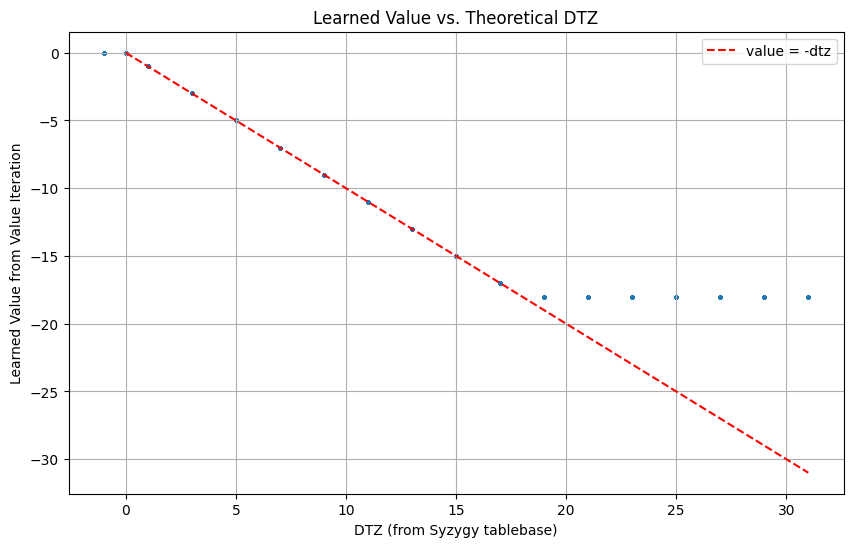

In [10]:
# load the value function
V = load_vf_parquet(VF_PATH + "vi_krk_greedy_intermediate_9.parquet")

# build a df with the theoretical DTZ for each FEN
V_df = pd.DataFrame.from_dict(V, orient='index', columns=['value']).reset_index().rename(columns={'index': 'fen'})
V_df['dtz'] = V_df['fen'].map(dtz_oracle)
V_df['gap'] = V_df['value'] + V_df['dtz']
V_df.sort_values('value')

# Plotting the relationship between the learned value and the theoretical DTZ
plt.figure(figsize=(10, 6))
plt.scatter(V_df['dtz'], V_df['value'], alpha=0.1, s=5)
plt.title('Learned Value vs. Theoretical DTZ')
plt.xlabel('DTZ (from Syzygy tablebase)')
plt.ylabel('Learned Value from Value Iteration')

# Add a reference line for value = -dtz
max_dtz = V_df['dtz'].max()
if pd.notna(max_dtz):
    plt.plot([0, max_dtz], [0, -max_dtz], color='red', linestyle='--', label='value = -dtz')

plt.grid(True)
plt.legend()
plt.show()

## Q-learning

In [11]:
# Load Q-Learning policy
qlearning_policy = load_policy_jsonl(POLICY_PATH + "TD_QLearning_krk_SyzygyDefender_greedy.jsonl")

# Create Q-learning agent from policy
qlearning_agent = move_from_policy_map(qlearning_policy)

In [12]:
df_q = evaluate(qlearning_agent, SyzygyDefender(TB_PATH), fens, dtm_oracle, optimal_moves=opt_moves)
df_q.groupby('dtm_oracle')['success'].mean()

dtm_oracle
1     1.000000
3     0.900000
5     0.960000
7     0.940000
9     0.940000
11    0.875000
13    1.000000
15    0.869565
17    0.928571
19    0.909091
21    1.000000
23    1.000000
25    0.875000
27    0.916667
29    1.000000
31    1.000000
Name: success, dtype: float64

In [13]:
df_q

,fen,dtm_policy,dtm_oracle,gap,success,ms_per_move,top1,top1_decisions
0,8/8/8/8/8/4R3/2K5/k7 w - - 0 1,1,1,0.0,1,0.003406,1.000000,1
1,8/8/k1K5/8/8/8/8/7R w - - 0 1,1,1,0.0,1,0.003041,1.000000,1
2,8/8/5K1k/8/8/8/3R4/8 w - - 0 1,7,1,6.0,1,0.003213,0.500000,4
3,8/8/4R3/8/8/2K5/8/2k5 w - - 0 1,1,1,0.0,1,0.002546,1.000000,1
4,8/7R/8/8/8/1K6/8/k7 w - - 0 1,7,1,6.0,1,0.002683,0.500000,4
...,...,...,...,...,...,...,...,...
315,K7/8/8/8/4R3/3k4/8/8 w - - 0 1,37,29,8.0,1,0.004210,0.894737,19
316,8/8/4k3/8/8/6R1/7K/8 w - - 0 1,35,29,6.0,1,0.002892,0.888889,18
317,7K/8/7R/5k2/8/8/8/8 w - - 0 1,39,29,10.0,1,0.003025,0.800000,20
318,2R5/8/8/8/8/3k4/K7/8 w - - 0 1,39,29,10.0,1,0.002842,0.750000,20


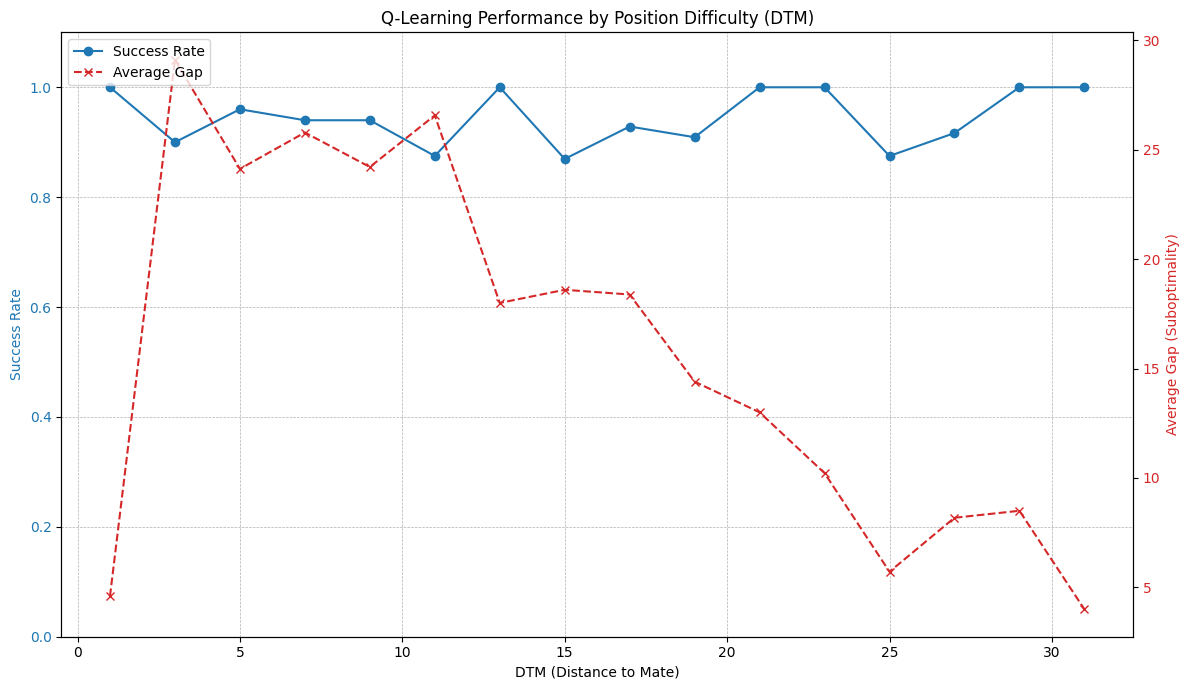

In [14]:
# Group by dtm_oracle to calculate success rate and average gap
q_eval_by_dtz = df_q.groupby('dtm_oracle').agg(
    success_rate=('success', 'mean'),
    avg_gap=('gap', 'mean')
).reset_index()

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Success Rate
color = 'tab:blue'
ax1.set_xlabel('DTM (Distance to Mate)')
ax1.set_ylabel('Success Rate', color=color)
ax1.plot(q_eval_by_dtz['dtm_oracle'], q_eval_by_dtz['success_rate'], color=color, marker='o', linestyle='-', label='Success Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.1)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Gap (Suboptimality)', color=color)
ax2.plot(q_eval_by_dtz['dtm_oracle'], q_eval_by_dtz['avg_gap'], color=color, marker='x', linestyle='--', label='Average Gap')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Q-Learning Performance by Position Difficulty (DTM)')
fig.tight_layout()

# Add a combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

In [15]:
df_success_q = df_q[df_q['success'] == 1]
df_success_q.groupby('dtm_oracle')['gap'].mean()

dtm_oracle
1      4.600000
3     29.111111
5     24.125000
7     25.787234
9     24.212766
11    26.571429
13    18.000000
15    18.600000
17    18.384615
19    14.400000
21    13.000000
23    10.222222
25     5.714286
27     8.181818
29     8.500000
31     4.000000
Name: gap, dtype: float64

In [16]:
df_success_q.groupby('dtm_oracle')['top1'].mean()

dtm_oracle
1     0.823333
3     0.716327
5     0.755515
7     0.729430
9     0.742345
11    0.742703
13    0.775329
15    0.779360
17    0.765566
19    0.795579
21    0.812996
23    0.810280
25    0.860731
27    0.826779
29    0.833406
31    0.888889
Name: top1, dtype: float64

### Trajectories

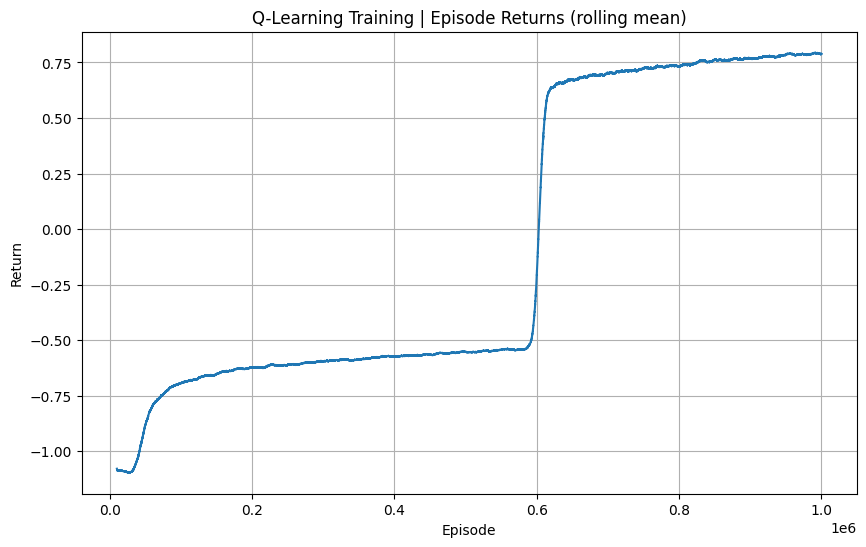

In [23]:
traj = pd.read_csv("./artifacts/metrics/TD_QLearning_krk_SyzygyDefender_returns.csv")
traj

traj['episode_return'].rolling(10000).mean().plot(
    figsize=(10, 6),
    title="Q-Learning Training | Episode Returns (rolling mean)",
    grid=True,
    xlabel="Episode",
    ylabel="Return"
)
plt.show()

## Actor-Critic

In [15]:
AC_PATH = "./python/chessrl/algorithms/actor_critic2/output/"
tb = SyzygyDefender(TB_PATH)
ac_move_fn = policy_mlp_move_from_checkpoint(
    AC_PATH + "actor_critic2_model_dtz3.pth",
    defender=tb,
    device=torch.device("cpu"),
    greedy=True
)

df = evaluate(
    move_fn=ac_move_fn,
    defender=tb,
    fens=fens,
    dtm_oracle=dtm_oracle,
    optimal_moves=opt_moves
)

df

,fen,dtm_policy,dtm_oracle,gap,success,ms_per_move,top1,top1_decisions
0,8/8/8/8/8/4R3/2K5/k7 w - - 0 1,14,1,NaN,0,5.181197,0.000000,7
1,8/8/k1K5/8/8/8/8/7R w - - 0 1,11,1,10.0,1,0.871758,0.500000,6
2,8/8/5K1k/8/8/8/3R4/8 w - - 0 1,100,1,NaN,0,1.021672,0.480000,50
3,8/8/4R3/8/8/2K5/8/2k5 w - - 0 1,7,1,6.0,1,0.937712,0.750000,4
4,8/7R/8/8/8/1K6/8/k7 w - - 0 1,5,1,4.0,1,0.920971,0.666667,3
...,...,...,...,...,...,...,...,...
315,K7/8/8/8/4R3/3k4/8/8 w - - 0 1,4,29,NaN,0,0.868879,0.000000,2
316,8/8/4k3/8/8/6R1/7K/8 w - - 0 1,4,29,NaN,0,0.813760,0.500000,2
317,7K/8/7R/5k2/8/8/8/8 w - - 0 1,6,29,NaN,0,2.002200,0.333333,3
318,2R5/8/8/8/8/3k4/K7/8 w - - 0 1,2,29,NaN,0,0.787340,0.000000,1


In [16]:
df.groupby('dtm_oracle')['success'].mean()

dtm_oracle
1     0.70
3     0.70
5     0.08
7     0.04
9     0.02
11    0.00
13    0.00
15    0.00
17    0.00
19    0.00
21    0.00
23    0.00
25    0.00
27    0.00
29    0.00
31    0.00
Name: success, dtype: float64

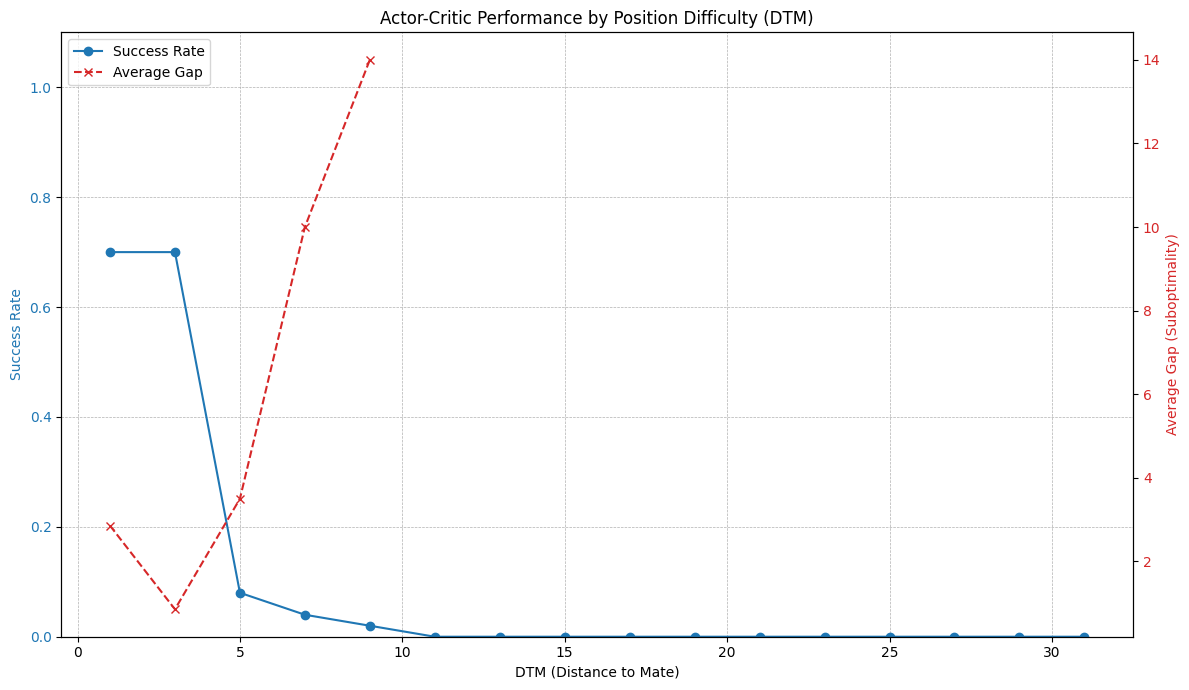

In [17]:
# Group by dtm_oracle to calculate success rate and average gap
ac_eval_by_dtz = df.groupby('dtm_oracle').agg(
    success_rate=('success', 'mean'),
    avg_gap=('gap', 'mean')
).reset_index()

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Success Rate
color = 'tab:blue'
ax1.set_xlabel('DTM (Distance to Mate)')
ax1.set_ylabel('Success Rate', color=color)
ax1.plot(ac_eval_by_dtz['dtm_oracle'], ac_eval_by_dtz['success_rate'], color=color, marker='o', linestyle='-', label='Success Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.1)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Gap (Suboptimality)', color=color)
ax2.plot(ac_eval_by_dtz['dtm_oracle'], ac_eval_by_dtz['avg_gap'], color=color, marker='x', linestyle='--', label='Average Gap')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Actor-Critic Performance by Position Difficulty (DTM)')
fig.tight_layout()

# Add a combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

### Critic Analysis

In [26]:
critic_w = np.load(AC_PATH + "critic_w.npy")
feature_names = [
    "bias",
    "d_edgeBK", "d_cornerBK",
    "dInf(WK,BK)", "dMan(WK,BK)",
    "dInf(WR,BK)", "dMan(WR,BK)",
    "aligned", "cut_w", "opp",
    "rook_adjBK",
    "same_file", "same_rank",
    "parity_sqBK",
    "side", "rook_present"
]

critic_df = pd.DataFrame({
    "feature": feature_names,
    "weight": critic_w
})

critic_df

,feature,weight
0,bias,-0.087685
1,d_edgeBK,-0.269029
2,d_cornerBK,-0.402305
3,"dInf(WK,BK)",-0.285990
4,"dMan(WK,BK)",-0.374517
5,"dInf(WR,BK)",-0.069399
6,"dMan(WR,BK)",0.200468
7,aligned,-0.000891
8,cut_w,0.103474
9,opp,-0.005332


the critic it’s a **linear value function**

$$
V(s) \approx \sum_i w_i \,\phi_i(s).
$$

Each weight tells whether increasing that feature makes the state look *better* (positive weight) or *worse* (negative weight) for White.

1. **bias = −0.088**
   Baseline offset. Slightly negative baseline, meaning "on average" positions are evaluated as a little worse than zero.

2. **d\_edgeBK = −0.269**
   Feature is *distance of Black King to edge*, the smaller the better (for White). 
   Negative weight means: as BK is farther from edge, value goes down.

3. **d\_cornerBK = −0.402**
   Feature is *distance of Black King to corner*, the smaller the better (for White).
   Negative weight means: as BK is farther from corner, value goes down.

4. **dInf(WK,BK) = −0.286**
   King–King Chebyshev distance.
   Negative weight means: as WK is farther from BK, value goes down.

5. **dMan(WK,BK) = −0.375**
   King–King Manhattan distance.
   Same interpretation.

6. **dInf(WR,BK) = −0.069**
   Rook–BK distance (Chebyshev).
   Slightly negative weight: critic prefers rook not to be *too far*. 

7. **dMan(WR,BK) = +0.200**
   Rook–BK distance (Manhattan).
   Positive weight: critic favors rook being farther on file/rank distance. This matches the heuristic: rook should cut the king off from a distance, not be adjacent.

9. **cut\_w = +0.103**
   Larger cut\_w means: when rook is aligned with the Black King, the Black King is farther from the nearest edge perpendicular to the rook’s fence. Smaller cut\_w means: the Black King is pressed nearer to that edge, i.e. boxed more tightly. This is counterintuitive since the smaller the better, but the weight is small so likely not significant or it is a bias from limited data.

Overall the critic seems to have learned the core geometry of KRK (push BK to edge/corner, bring WK closer, rook should cut from afar). That’s already promising.
The smaller/strange weights (rook_adjBK, rook_present, side) are likely artifacts of limited training data (or very strong constrain over max step) or feature collinearity. The **magnitudes** are small (−0.40 to +0.20), suggesting learning didn’t drive very strong preferences yet.

## MCTS

In [19]:
from chessrl.algorithms.mcts.mcts import MCTS

dfs = []
tb = SyzygyDefender(TB_PATH)
fens[0]

'8/8/8/8/8/4R3/2K5/k7 w - - 0 1'

In [9]:
for fen in example_fens[3:4]:
    mcts = MCTS(seconds=10.0, iterations=20_000, use_env_in_rollout=True,
                defender=tb, absorb_black_reply=True)
    mcts_move_fn = mcts_move_from_instance(mcts)

    df = evaluate(
        move_fn=mcts_move_fn,
        defender=tb,
        fens=[fen],
        dtm_oracle=dtm_oracle,
        optimal_moves=opt_moves
    )
    dfs.append(df)

df_mcts = pd.concat(dfs, ignore_index=True)
df_mcts

,fen,dtm_policy,dtm_oracle,gap,success,ms_per_move,top1,top1_decisions
0,4R3/8/8/8/8/4K3/8/7k w - - 0 1,3,3,0,1,8013.175750,1.00,2
1,4k3/8/8/4K3/8/4R3/8/8 w - - 0 1,5,5,0,1,8603.797621,1.00,3
2,8/1R6/8/8/K7/8/k7/8 w - - 0 1,100,7,None,0,10007.775440,0.24,50



Top 5 white moves from root:
 1.   e3a3  visits=  4897  pct= 97.9%  Q=+1.0000  UCT=+1.0590
 2.   e3c3  visits=    10  pct=  0.2%  Q=-0.3562  UCT=+0.9490
 3.   e3e4  visits=     8  pct=  0.2%  Q=-0.4388  UCT=+1.0205
 4.   e3e2  visits=     5  pct=  0.1%  Q=-0.8457  UCT=+1.0001
 5.   e3e7  visits=     5  pct=  0.1%  Q=-0.8516  UCT=+0.9942


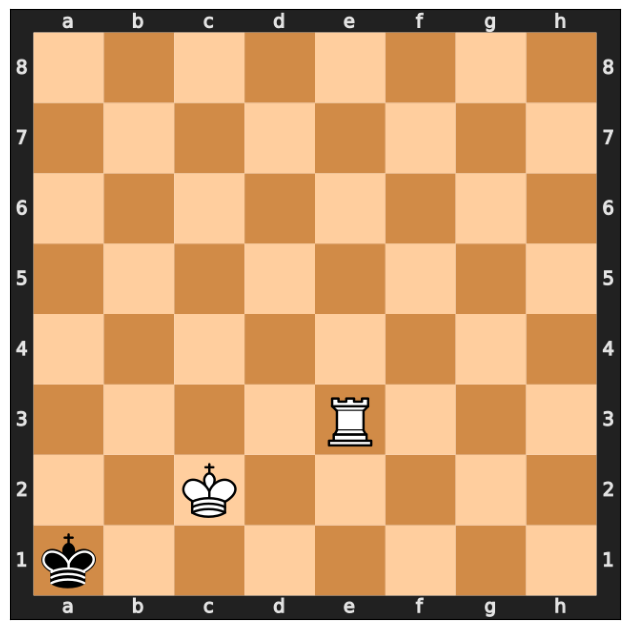

In [21]:
from chessrl import chess_py as cp
from chessrl.utils.plot_chess import plot_game

g = cp.Game()
g.reset_from_fen("8/8/8/8/8/4R3/2K5/k7 w - - 0 1")  # example
plot_game(g)
mcts = MCTS(seconds=10.0, iterations=5_000, use_env_in_rollout=True,
            defender=defender, absorb_black_reply=True)
best = mcts.search_with_stats(g)